# Artificial Neural Network (ANN)

An Artificial Neural Network (ANN) is a machine learning model inspired by the human brain. It is mainly used for:

- Classification (Spam detection, sentiment analysis)
- Regression (Price prediction)
- Image recognition
- Natural Language Processing
- Pattern recognition

ANN is a core part of Deep Learning and Artificial Intelligence.

### There are 3 Layers in This 

- Input Layer
- Hidden Layer
- Output Layer

### Output=Activation((W×X)+B)

## Activation Functions
a mathematical formula applied to a neuron's output in a neural network to introduce nonlinearity, allowing the model to learn complex, non-linear patterns in data

### Common Activation Functions
- ReLU → Most used in hidden layers
- Sigmoid → Binary classification
- Softmax → Multi-class classification

In [1]:
!pip install numpy pandas matplotlib tensorflow scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv('Iris.csv')

In [4]:
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
dataset.drop(columns=['Id'])

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
X=dataset.drop(columns=['Id','Species'])
y=dataset['Species']

In [17]:

from sklearn.calibration import LabelEncoder


species=LabelEncoder()
y=species.fit_transform(y)


In [45]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Sequential → A Keras model where layers are stacked one after another in order.

In [60]:
model = Sequential()    

In [61]:
model.add(Input(shape=(4,)))

Dense: A fully connected layer; 16, 8, 3 mean the number of neurons in that layer (last one = number of classes).

In [ ]:
# Input + Hidden Layer 1
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

In [63]:
# Hidden Layer 2
model.add(Dense(units=8, activation='relu'))

In [64]:
# Output Layer
model.add(Dense(units=3, activation='softmax'))

In [65]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Adam Optimizer → An algorithm that adjusts weights automatically using adaptive learning rates to minimize loss.

sparse_categorical_crossentropy → A loss function for multi-class classification when labels are integers (0,1,2).

In [ ]:
model.summary()

In [55]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

Epoch → One complete pass of the entire training dataset through the model.

In [66]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)   

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - accuracy: 0.3438 - loss: 1.2836 - val_accuracy: 0.2917 - val_loss: 1.4989
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3438 - loss: 1.2452 - val_accuracy: 0.2917 - val_loss: 1.4506
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3229 - loss: 1.2045 - val_accuracy: 0.2917 - val_loss: 1.4071
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.3333 - loss: 1.1722 - val_accuracy: 0.3333 - val_loss: 1.3644
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4375 - loss: 1.1397 - val_accuracy: 0.3750 - val_loss: 1.3242
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5833 - loss: 1.1062 - val_accuracy: 0.4583 - val_loss: 1.2869
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6146 - loss: 1.0772 - val_accuracy: 0.5000 - val_loss: 1.2514
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5938 - loss: 1.0486 - val_accuracy: 0.5000 - val_loss: 

In [68]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6333 - loss: 0.9065
Test Accuracy: 0.6333333253860474


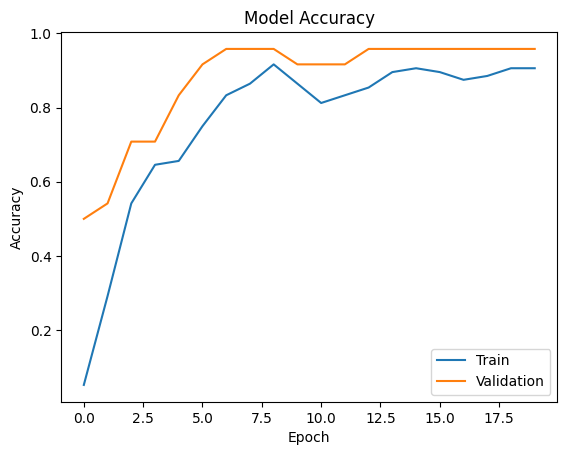

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


#### Take Prediction on One Sample

In [77]:
import numpy as np

test_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # convert list → numpy

prediction = model.predict(test_sample)

print("Predicted probabilities:", prediction)
predicted_class = prediction.argmax()

print(predicted_class)
predicted_label = species.inverse_transform([predicted_class])

print("Predicted class:", predicted_label[0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Predicted probabilities: [[0.60498595 0.25802702 0.13698709]]
0
Predicted class: Iris-setosa
